## Ocular Disease Detection with Pytorch

by Stan Chen,  https://www.linkedin.com/in/y-stan-chen/, https://github.com/OhStan    
Data Source: [Ocular Disease Dataset on Kaggle](https://www.kaggle.com/datasets/manan1717/ocular-disease-dataset)

In [1]:
# Import needed packages
import os, datetime, sys, random
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)
pd.options.display.float_format = '{:20,.3f}'.format

from sklearn.model_selection import train_test_split
import numpy as np
from collections import defaultdict, Counter

from torch.utils.data import Dataset, DataLoader
import torch, torchvision
import torchvision.transforms.v2 as T
import torchvision.io as tv_io
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

import cv2
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

from torchinfo import summary
from IPython.display import display, clear_output

%matplotlib inline

## Let's check the versions

In [2]:
print("Python Version:\n", sys.version)

Python Version:
 3.12.13 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:38:16) [GCC 14.3.0]


In [3]:
print("PyTorch Version:\n", torch.__version__)

PyTorch Version:
 2.13.0+cu130


In [4]:
# Get number of CPUs on this machine
import multiprocessing
n_cpu = multiprocessing.cpu_count()
print("CPU Count:",n_cpu)

# Check if cuda gpu is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#model.to(device)
print("The Device:", device)

if torch.cuda.is_available():
    #device = torch.device("cuda")
    gpu_name = torch.cuda.get_device_name(device)
    print(f"GPU name: {gpu_name}")
    # Number of GPUs
    print("Number of GPUs:", torch.cuda.device_count())
    # GPU memory
    print("Total memory:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")
else:
    print("No GPUs available.")

CPU Count: 24
The Device: cuda
GPU name: NVIDIA GeForce RTX 4070
Number of GPUs: 1
Total memory: 11.99 GB


## To load the image data

In [5]:
# First check current working dir
cwd = os.getcwd()
print(cwd)

/home/ddbbx_wsl/OcularDisease


In [6]:
# Set the image data dir
DATA_DIR = r"/home/ddbbx_wsl/OcularDisease/OcularDiseaseData/preprocessed" 
SUPPORTED_EXTENSIONS = (".jpg", ".jpeg", ".png")

In [7]:
# Get the class names from the folder names, since each class of images were stored in their own folders 
class_names = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])


In [8]:
# Check if class names are correct
print("Class Names: \n",class_names)
print("Total Classes:", len(class_names))

Class Names: 
 ['A', 'C', 'D', 'G', 'H', 'M', 'N']
Total Classes: 7


In [9]:
# Enumerate the class_name 
class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

In [10]:
# Check enumeration is done properly
print(class_to_idx)
print()

{'A': 0, 'C': 1, 'D': 2, 'G': 3, 'H': 4, 'M': 5, 'N': 6}



In [11]:
# Get the path for all image and their labels

image_paths = []
labels = []

for class_name in class_names:
    class_folder = os.path.join(DATA_DIR, class_name)
    for file in os.listdir(class_folder):
        if file.lower().endswith(SUPPORTED_EXTENSIONS):
            image_paths.append(os.path.join(class_folder, file))
            labels.append(class_to_idx[class_name])

In [12]:
print(len(image_paths))
print(len(labels))

10449
10449


In [13]:
# Let's do some counts of each class

rawclass_counts = Counter(labels)

In [14]:
# Convert counts to a list of dicts, mapping the IDs to their letter names
list_rawcounts = []
for class_idx, count in rawclass_counts.items():
    list_rawcounts.append({
        "Class_id": class_idx,
        "class_name": idx_to_class[class_idx],  # Your letter-folder dictionary
        "Counts": count
    })

# Create the DataFrame and sort it numerically by class_id
df_rawcounts = pd.DataFrame(list_rawcounts).sort_values("Class_id").reset_index(drop=True)
df_rawcounts.set_index('Class_id', inplace=True)

In [15]:
# Add the relative frequencies
df_rawcounts['RelFreq'] = df_rawcounts['Counts']/df_rawcounts['Counts'].sum()
df_rawcounts['RelFreq'] = df_rawcounts['RelFreq'].round(4)

In [16]:
# Add the full names
FullName = ["Age-related Macular Degeneration", "Cataract", "Diabetic Retinopathy", "Glaucoma", "Hypertensive Retinopathy", 
            "Myopia", "Normal"]

df_rawcounts['FullName'] = FullName


In [17]:
print(df_rawcounts)

         class_name  Counts              RelFreq                          FullName
Class_id                                                                          
0                 A     511                0.049  Age-related Macular Degeneration
1                 C    1008                0.097                          Cataract
2                 D    3128                0.299              Diabetic Retinopathy
3                 G    1646                0.158                          Glaucoma
4                 H     420                0.040          Hypertensive Retinopathy
5                 M     739                0.071                            Myopia
6                 N    2997                0.287                            Normal


## Recap the Labels and Class Distribution
Disease Class || Image Count  
Age-related Macular Degeneration (A) || 511  
Cataract (C) || 1,008  
Diabetic Retinopathy (D) || 3,128  
Glaucoma (G) || 1,646  
Hypertensive Retinopathy (H) || 420  
Myopia (M) || 739  
Normal (N) || 2,997  
Total || 10,449  

## Now let's do some preview of raw image, with torchvision.io.read_image

In [18]:
def preview_raw_samples_per_class(image_paths, labels, idx_to_class_map, samples_per_class=3, randseed = None):
    """
    Groups image paths by class and displays a grid with 'samples_per_class' 
    raw images for each category in their own row.
    """
    # 1. Group the image paths by their class index
    class_groups = defaultdict(list)
    for path, label in zip(image_paths, labels):
        class_groups[label].append(path)
        
    # Get sorted class indices so the grid displays alphabetically/numerically
    sorted_class_indices = sorted(class_groups.keys())
    num_classes = len(sorted_class_indices)
    
    # 2. Setup the plotting grid (Rows = Classes, Cols = Samples per class)
    fig, axes = plt.subplots(
        nrows=num_classes, 
        ncols=samples_per_class, 
        figsize=(samples_per_class * 3.5, num_classes * 3)
    )
    
    # Ensure axes is a 2D array even if we only have 1 class or 1 sample
    if num_classes == 1:
        axes = axes.reshape(1, -1)
    elif samples_per_class == 1:
        axes = axes.reshape(-1, 1)

    # 3. Sample and plot
    for row_idx, class_idx in enumerate(sorted_class_indices):
        class_name = idx_to_class_map[class_idx]
        paths_in_class = class_groups[class_idx]
        
        # Randomly sample paths (handle cases where a class might have fewer images than requested)
        num_to_sample = min(samples_per_class, len(paths_in_class))
        random.seed(randseed)
        sampled_paths = random.sample(paths_in_class, num_to_sample)
        
        for col_idx in range(samples_per_class):
            ax = axes[row_idx, col_idx]
            
            if col_idx < len(sampled_paths):
                path = sampled_paths[col_idx]
                
                # Load raw RGB tensor directly from disk
                raw_tensor = tv_io.read_image(path, mode=tv_io.ImageReadMode.RGB)
                raw_numpy = raw_tensor.permute(1, 2, 0).numpy()
                
                # Plot
                ax.imshow(raw_numpy)
                # We show the class label on the far left column to keep the grid clean
                if col_idx == 0:
                    ax.set_title(f"Class [{class_name}]\n{raw_numpy.shape[1]}x{raw_numpy.shape[0]}", fontsize=11, fontweight="bold", loc="left")
                else:
                    ax.set_title(f"{raw_numpy.shape[1]}x{raw_numpy.shape[0]}", fontsize=9)
            else:
                # If there are not enough images in this class to fill the column, show a blank cell
                ax.text(0.5, 0.5, "No Image", ha='center', va='center', color='gray')
                
            ax.axis('off')
            
    plt.tight_layout()
    plt.show()



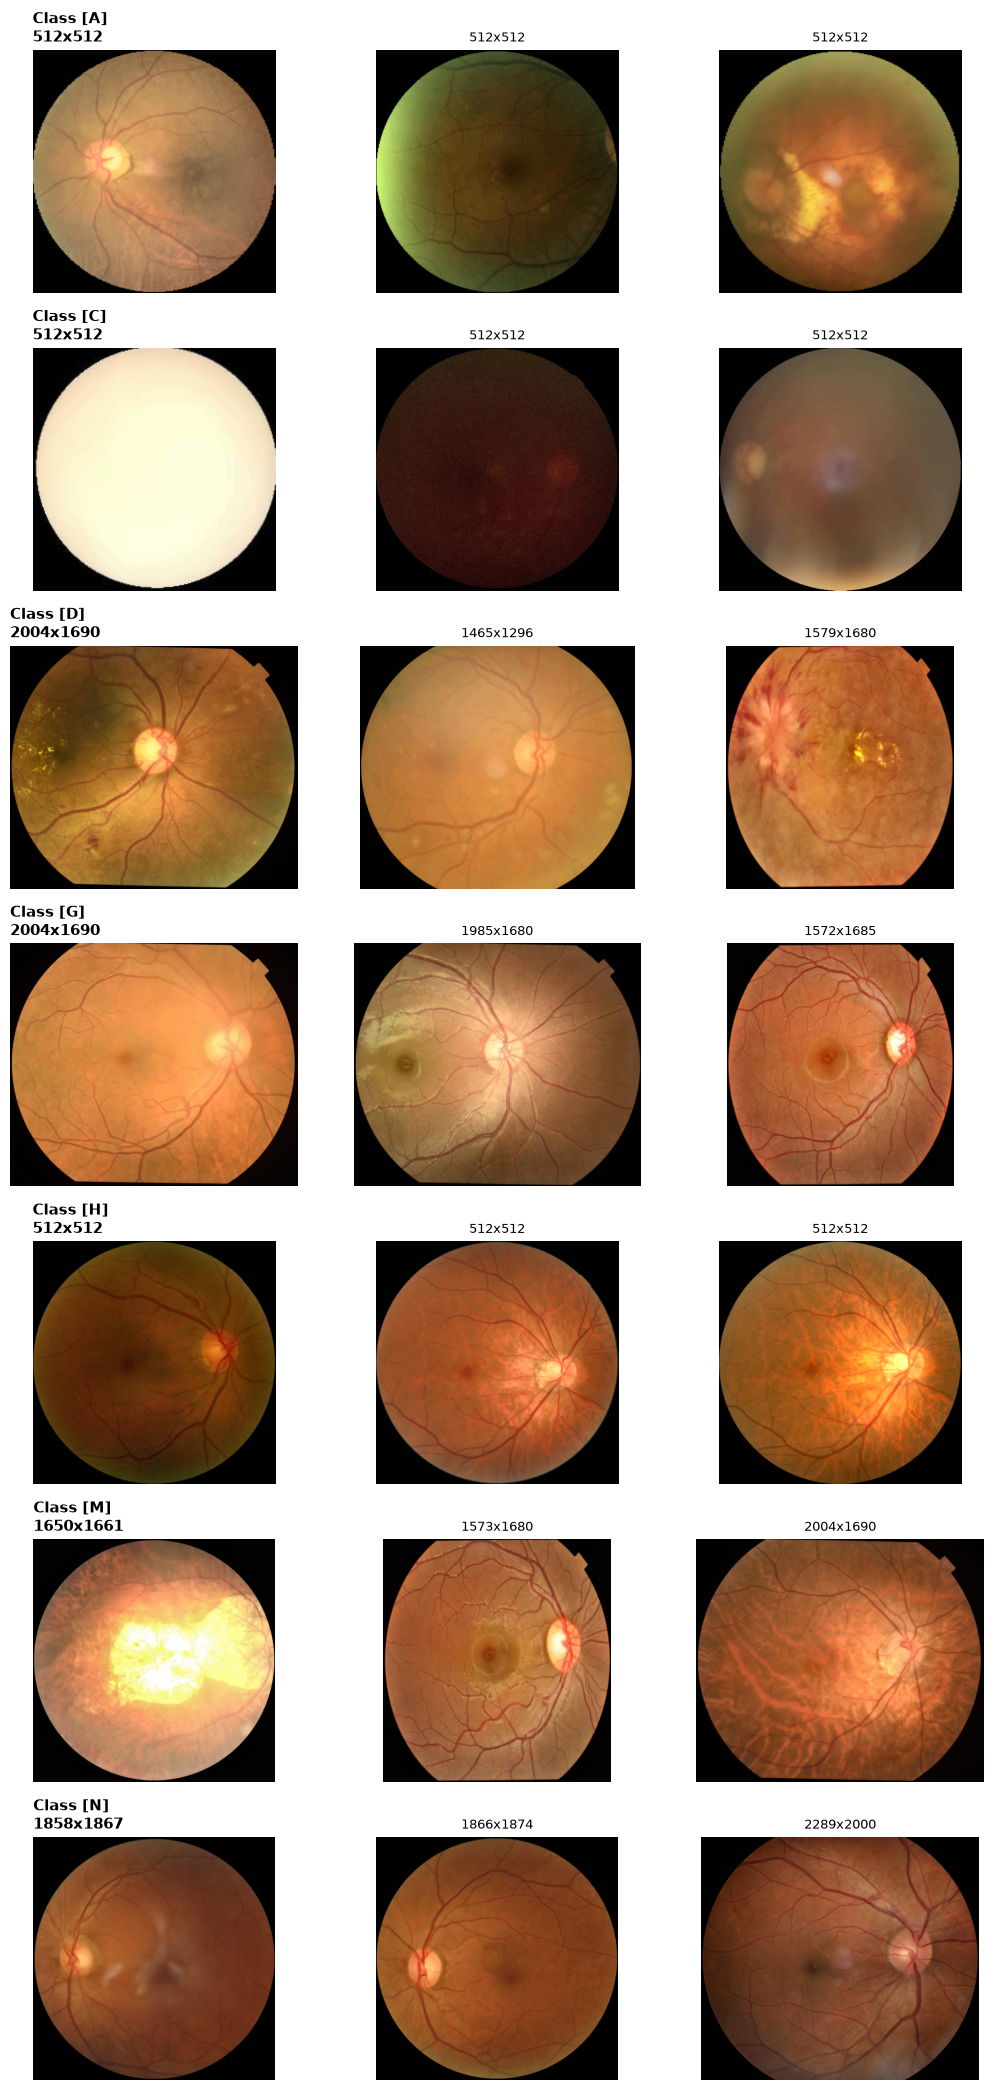

In [19]:
# --- RUN THE PREVIEW ---
# We set the seed for random here for reproducibility

preview_raw_samples_per_class(
    image_paths=image_paths, 
    labels=labels, 
    idx_to_class_map=idx_to_class, 
    samples_per_class=3,
    randseed = 987654321
)

## Note that the images are in different sizes

## Now we do the data split for the directories of the images, which will be loaded latter with dataloaded accordingly. We want to have train:val:test = 70:15:15 

In [20]:
# Do the data split
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, 
    labels, 
    test_size=0.30, 
    random_state= 143258769, 
    stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, 
    temp_labels, 
    test_size=0.50, 
    random_state= 143258769, 
    stratify=temp_labels
)



In [21]:
# Check the outcome of split
print("Train split size:", len(train_paths))
print("Val split size:", len(val_paths))
print("Test split size:", len(test_paths))

Train split size: 7314
Val split size: 1567
Test split size: 1568


In [22]:
# Check the output distribution of the split
print("y_train distribution:", np.round(np.bincount(train_labels)/len(train_labels), 4) )
print("y_val distribution:",  np.round(np.bincount(val_labels)/len(val_labels), 4))
print("y_test distribution:",  np.round(np.bincount(test_labels)/len(test_labels), 4) )

y_train distribution: [0.0489 0.0965 0.2993 0.1575 0.0402 0.0707 0.2868]
y_val distribution: [0.0491 0.0964 0.2993 0.1576 0.0402 0.0708 0.2865]
y_test distribution: [0.0485 0.0963 0.2997 0.1575 0.0402 0.0708 0.287 ]


## Now we create the dataloader

In [23]:
# Define the random seed for reproducibility
seed = 123454321

torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [24]:
# Define dataset class, we want to load the data into memory so we can accelerate 
class InMemoryDataset(Dataset):

    def __init__(self, paths, labels, preprocess, transform):

        self.transform = transform
        self.labels = torch.tensor(labels)

        images = []

        for path in paths:
            img = tv_io.read_image(path)
            img = preprocess(img)      # always preprocess
            images.append(img)

        self.images = torch.stack(images)

    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):

        image = self.images[idx]
        
        if self.transform is not None:
            image = self.transform(image)  # always transform
        
        return image, self.labels[idx], idx


In [25]:
# --- DEFINE TRANSFORMS ---
# This preprocess will be used by train, val, test
# Applied once when loading into RAM

preprocess = T.Compose([
    T.Resize((256, 256)),
    T.ToDtype(torch.float32, scale=True)
])


In [26]:
# We want to find the mean and std for our training set
# First create a temporary training loader
train_dataset_no_norm = InMemoryDataset(
    train_paths,
    train_labels,
    preprocess= preprocess,
    transform=None
)

train_loader_no_norm = DataLoader(
    train_dataset_no_norm,
    batch_size=128,
    shuffle=False
)

In [27]:
# Find the mean and std for our training set
train_mean = torch.zeros(3)
train_std = torch.zeros(3)

count = 0

for images, labels, _ in train_loader_no_norm:

    # images shape:
    # batch x channel x height x width

    batch_samples = images.size(0)

    images = images.view(batch_samples, 3, -1)

    train_mean += images.mean(2).sum(0)

    train_std += images.std(2).sum(0)

    count += batch_samples


train_mean /= count
train_std /= count

train_mean = train_mean.tolist()
train_std = train_std.tolist()

print("Training Set Mean:", train_mean)
print("Training Set Std:", train_std)

Training Set Mean: [0.49856576323509216, 0.3075774312019348, 0.15830962359905243]
Training Set Std: [0.2715822756290436, 0.17515437304973602, 0.09590897709131241]


In [28]:
# --- DEFINE TRANSFORMS --- continued

# Training: resize, apply light augmentations, convert to 0.0 - 1.0 float, normalize
train_transforms = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1),
    T.Normalize(mean= train_mean, std= train_std)
])

# Testing: resize, convert to 0.0 - 1.0 float, normalize, NO augmentation
test_transforms = T.Compose([
    T.Normalize(mean= train_mean, std= train_std)
])



In [29]:
# Create datasets, here the data will be loaded into memory

# Let's track the time as well
memload_start_time = datetime.datetime.now()
print(f"Loading data into memory, at {str(memload_start_time)[0:19]}, please wait...")


train_dataset = InMemoryDataset(train_paths, train_labels, preprocess=preprocess, transform=train_transforms)
val_dataset = InMemoryDataset(val_paths, val_labels, preprocess=preprocess, transform=test_transforms)
test_dataset = InMemoryDataset(test_paths, test_labels, preprocess=preprocess, transform=test_transforms)


memload_end_time = datetime.datetime.now()
LoadTime = memload_end_time - memload_start_time
print(f"Loading started at:{str(memload_start_time)[0:19]}, ended at:{str(memload_end_time)[0:19]}, loading time spent:{str(LoadTime)}")

Loading data into memory, at 2026-07-18 18:53:53, please wait...
Loading started at:2026-07-18 18:53:53, ended at:2026-07-18 18:57:10, loading time spent:0:03:16.875316


In [30]:
# Create dataloaders

g = torch.Generator()
g.manual_seed(seed)

train_loader = DataLoader(train_dataset, batch_size= 64, shuffle=True, num_workers= 0, pin_memory=True, generator=g)

# val and test loader do not need the random generator, since they aren't shuffling
val_loader = DataLoader(val_dataset, batch_size= 64, shuffle=False, num_workers= 0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size= 64, shuffle=False, num_workers= 0, pin_memory=True)

## Define the CNN Architecture

In [31]:
# Add the Convolutional Block Attention Module,  a lightweight attention mechanism

# Add Channel Attention 
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.mlp = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.mlp(self.avg_pool(x))
        mx = self.mlp(self.max_pool(x))
        return self.sigmoid(avg + mx)



# Add Spatial Attention
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()

        padding = kernel_size // 2

        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size,
            padding=padding,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg, mx], dim=1)
        x = self.conv(x)

        return self.sigmoid(x)



# Add CBAM
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()

        self.channel = ChannelAttention(channels, reduction)
        self.spatial = SpatialAttention()

    def forward(self, x):

        x = x * self.channel(x)
        x = x * self.spatial(x)
        return x



In [32]:

class CNNet(nn.Module):
    def __init__(self, num_classes= len(class_names)):
        super(CNNet, self).__init__()
        
        self.model = nn.Sequential(
            # conv1 + batchnorm + relu + maxpool
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),            # 
            nn.MaxPool2d(2, 2),   # 
            
            # Block 2: 
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Block 3: 
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            #CBAM(128),        #
            nn.MaxPool2d(2, 2),
            
            # Block 4: 
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            #CBAM(256),        #
            nn.MaxPool2d(2, 2),
            
            # Block 5: 
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            CBAM(512),        #
            nn.MaxPool2d(2, 2),

            # conv6 + batchnorm + relu
            nn.Conv2d(512, 512, kernel_size=3, padding=1),   
            nn.BatchNorm2d(512),
            nn.ReLU(),
            CBAM(512), 
                  
            # AdaptiveAvgPool2d layer
            nn.AdaptiveAvgPool2d((2, 2)),  # convert all to 1 * 1
            # Flatten feature maps
            nn.Flatten(),
            
            # Fully Connected, 512 * (1 * 1)
            nn.Linear(512 * 2 * 2, 256),   
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, 128),      # add one more FC layer
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [33]:
model = CNNet(num_classes= len(class_names) )

# Place wt on labels because class 2 have been mistaken as class 6 badly
label_weights = torch.tensor([1.0, 1.0, 1.1, 1.0, 1.0, 1.0, 1.0]).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1, weight = label_weights)   # for multi-class classification
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model.to(device)

CNNet(
  (model): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True,

In [34]:
# print the model summary, torchinfo.summary requires input (Batch Size, Channels, Height, Width)

# Remember to put model in eval() mode so it does not disturb prior to training

model.eval()
print(summary(model, input_size=(1, 3, 256, 256)))
model.train()

Layer (type:depth-idx)                        Output Shape              Param #
CNNet                                         [1, 7]                    --
├─Sequential: 1-1                             [1, 7]                    --
│    └─Conv2d: 2-1                            [1, 32, 256, 256]         896
│    └─BatchNorm2d: 2-2                       [1, 32, 256, 256]         64
│    └─ReLU: 2-3                              [1, 32, 256, 256]         --
│    └─MaxPool2d: 2-4                         [1, 32, 128, 128]         --
│    └─Conv2d: 2-5                            [1, 64, 128, 128]         18,496
│    └─BatchNorm2d: 2-6                       [1, 64, 128, 128]         128
│    └─ReLU: 2-7                              [1, 64, 128, 128]         --
│    └─MaxPool2d: 2-8                         [1, 64, 64, 64]           --
│    └─Conv2d: 2-9                            [1, 128, 64, 64]          73,856
│    └─BatchNorm2d: 2-10                      [1, 128, 64, 64]          256
│    └─Re

CNNet(
  (model): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True,

## Set up the training with validation

In [35]:
best_val_loss = float('inf')
patience = 20
pcounter = 0

best_model_dir = "bestmodel_ocular_pytorch.pth"
best_epoch = 1

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
num_epochs = 500

#scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.1)

for epoch in range(num_epochs):

    ep_start_time = datetime.datetime.now()
    # ===== TRAIN =====
    model.train()
    train_loss = 0.0

    correct = 0
    total = 0
    
    for images, labels, _ in train_loader:
        images = images.to(device)
        labels = labels.to(device).long()
        
        # forward
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)          
        total += labels.size(0)                         
        correct += (predicted == labels).sum().item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    epoch_acc = correct / total
    train_accuracies.append(epoch_acc)
   
    # ===== VALIDATE =====
    model.eval()
    val_loss = 0.0

    val_correct = 0
    val_total = 0
    
    with torch.no_grad():  
        for images, labels, _ in val_loader:
            images = images.to(device)
            labels = labels.to(device).long()
            
            outputs = model(images)
            
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
    
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    #scheduler.step()
    #current_lr = optimizer.param_groups[0]['lr']
    
    ep_val_acc = val_correct / val_total
    val_accuracies.append(ep_val_acc)
    
    TimeDiff = datetime.datetime.now() - ep_start_time
    # ===== PRINT =====
    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, " 
          f"Train Acc = {epoch_acc:.4f}, Val Acc = {ep_val_acc:.4f}, "
          #f"LR = {current_lr:.6f}, "
          f"time spent:", str(TimeDiff))

    if epoch == num_epochs - 1:
        print("Training terminated with maximum number of loops at epoch:", str(epoch+1))
        
    # ===== EARLY STOPPING + SAVE BEST MODEL =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        pcounter = 0
        
        torch.save(model.state_dict(), best_model_dir)
        best_epoch = epoch + 1
        print("Model improved. Saved. Best Epoch is:", best_epoch)
    else:
        pcounter += 1
        print(f"No improvement. Current Patience: {pcounter}/{patience}")

        if pcounter >= patience:
            print("Early stopping triggered. Best model obtained at epoch:", best_epoch)
            break

Epoch 1: Train Loss = 1.6479, Val Loss = 1.4844, Train Acc = 0.3984, Val Acc = 0.4627, time spent: 0:00:21.754212
Model improved. Saved. Best Epoch is: 1
Epoch 2: Train Loss = 1.4643, Val Loss = 1.4222, Train Acc = 0.4995, Val Acc = 0.5227, time spent: 0:00:21.393132
Model improved. Saved. Best Epoch is: 2
Epoch 3: Train Loss = 1.3670, Val Loss = 1.4528, Train Acc = 0.5488, Val Acc = 0.5061, time spent: 0:00:21.364997
No improvement. Current Patience: 1/20
Epoch 4: Train Loss = 1.3141, Val Loss = 1.2397, Train Acc = 0.5662, Val Acc = 0.5820, time spent: 0:00:21.350515
Model improved. Saved. Best Epoch is: 4
Epoch 5: Train Loss = 1.2679, Val Loss = 1.2045, Train Acc = 0.5856, Val Acc = 0.6165, time spent: 0:00:21.239380
Model improved. Saved. Best Epoch is: 5
Epoch 6: Train Loss = 1.2346, Val Loss = 1.1569, Train Acc = 0.6081, Val Acc = 0.6311, time spent: 0:00:21.529534
Model improved. Saved. Best Epoch is: 6
Epoch 7: Train Loss = 1.1736, Val Loss = 1.1530, Train Acc = 0.6408, Val Acc 

## Make the plot for train loss and val loss

<Figure size 640x480 with 0 Axes>

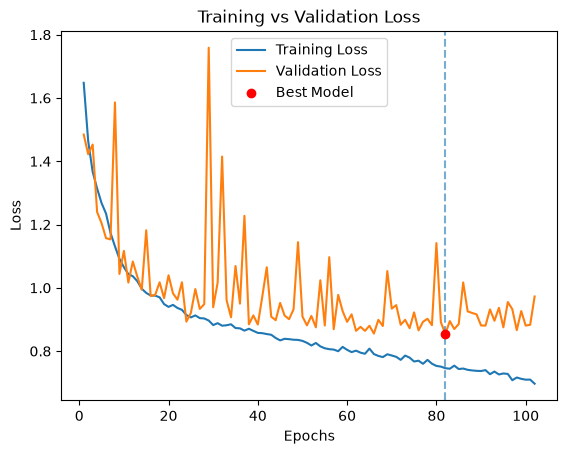

In [36]:
# Produce x-axis base on epochs
epoch_list = list(range(1, len(train_losses) + 1))
best_val = val_losses[best_epoch - 1]

# Make the plot
plt.clf()
plt.figure()
plt.plot(epoch_list, train_losses, label='Training Loss')
plt.plot(epoch_list, val_losses, label='Validation Loss')

# Labels and title
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.scatter(best_epoch, best_val, color='red', zorder=5, label='Best Model')
plt.axvline(x=best_epoch, linestyle='--', alpha=0.6)

# Legend
plt.legend()

# Show plot
plt.show()

## Load the best model, then evaluation with test set

In [37]:
# Load best model then evaluate
model.load_state_dict(torch.load(best_model_dir, map_location=device))
model.to(device)
model.eval() # switch to evaluation mode

print("Device loaded to:", next(model.parameters()).device)

# Do overall test accuracy
correct = 0
total = 0

all_preds = []
all_labels = []
all_indices = []
all_probs = []  

with torch.no_grad(): 
    for images, labels, indices in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images) 
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1) 
        
        total += labels.size(0)
        correct += (preds == labels).sum().item()
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_indices.extend(indices.numpy())

        all_probs.extend(probs.cpu().numpy())

test_acc = correct / total
print(f"Test Overall Accuracy: {test_acc:.4f}")

Device loaded to: cuda:0
Test Overall Accuracy: 0.7742


## Get per class accuracy with test data

In [38]:
# Do per class accuracy
class_correct = [0] * 7
class_total = [0] * 7

with torch.no_grad():
    for images, labels, _ in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):
            label = labels[i]
            class_total[label] += 1
            if predicted[i] == label:
                class_correct[label] += 1

for i in range(7):
    print(f"Class {i}: {class_correct[i] / class_total[i]:.4f}")

Class 0: 0.8421
Class 1: 0.9934
Class 2: 0.7191
Class 3: 0.7976
Class 4: 0.6349
Class 5: 0.7387
Class 6: 0.7622


## Do confusion matrix

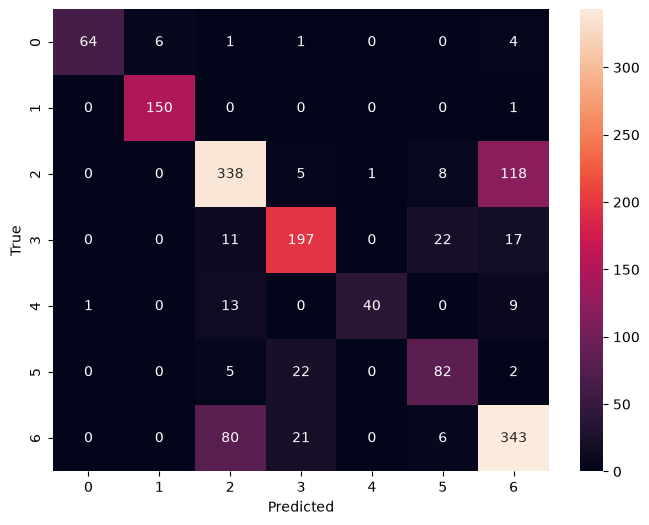

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [40]:
# print the cm
print(cm)

[[ 64   6   1   1   0   0   4]
 [  0 150   0   0   0   0   1]
 [  0   0 338   5   1   8 118]
 [  0   0  11 197   0  22  17]
 [  1   0  13   0  40   0   9]
 [  0   0   5  22   0  82   2]
 [  0   0  80  21   0   6 343]]


## Do the overall precision_score, recall_score, f1_score,

In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score


overall_precision = precision_score(all_labels, all_preds, average='weighted')  
overall_recall = recall_score(all_labels, all_preds, average='weighted')
overall_f1 = f1_score(all_labels, all_preds, average='weighted')

In [42]:
# Print the metrics, include the overall accuracy

print(f"Test Overall Accuracy: {test_acc:.4f}")
print(f"Overall Precision: {overall_precision:.4f}")
print(f"Overall Recall:    {overall_recall:.4f}")
print(f"Overall F1 Score:  {overall_f1:.4f}")

Test Overall Accuracy: 0.7742
Overall Precision: 0.7803
Overall Recall:    0.7742
Overall F1 Score:  0.7749


In [43]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9846    0.8421    0.9078        76
           1     0.9615    0.9934    0.9772       151
           2     0.7545    0.7191    0.7364       470
           3     0.8008    0.7976    0.7992       247
           4     0.9756    0.6349    0.7692        63
           5     0.6949    0.7387    0.7162       111
           6     0.6943    0.7622    0.7267       450

    accuracy                         0.7742      1568
   macro avg     0.8380    0.7840    0.8047      1568
weighted avg     0.7803    0.7742    0.7749      1568



## Let's find out more about class 2 to 6 errors

In [44]:
# Find class 2 to 6 errors

list_class2_to_6 = []

for label, pred, idx, prob in zip(
        all_labels,
        all_preds,
        all_indices,
        all_probs):

    if label == 2 and pred == 6:

        confidence = prob[6]  # confidence of predicted class 6

        list_class2_to_6.append(
            (idx, confidence)
        )

print("Number of Class 2 predicted as Class 6:",
      len(list_class2_to_6))

Number of Class 2 predicted as Class 6: 118


In [45]:
# Sort the list of class 2 to 6 by confidence, to review the most prominent cases

list_class2_to_6.sort(key=lambda x: x[1], reverse=True)

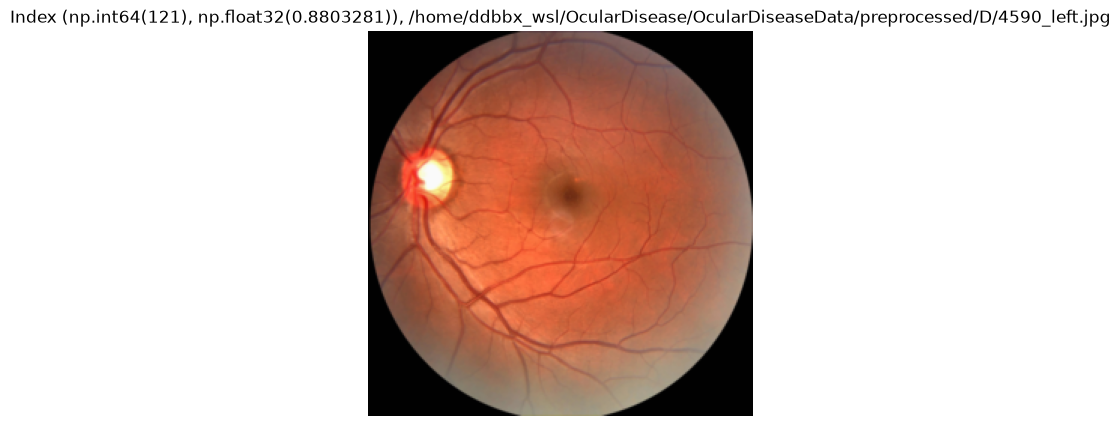

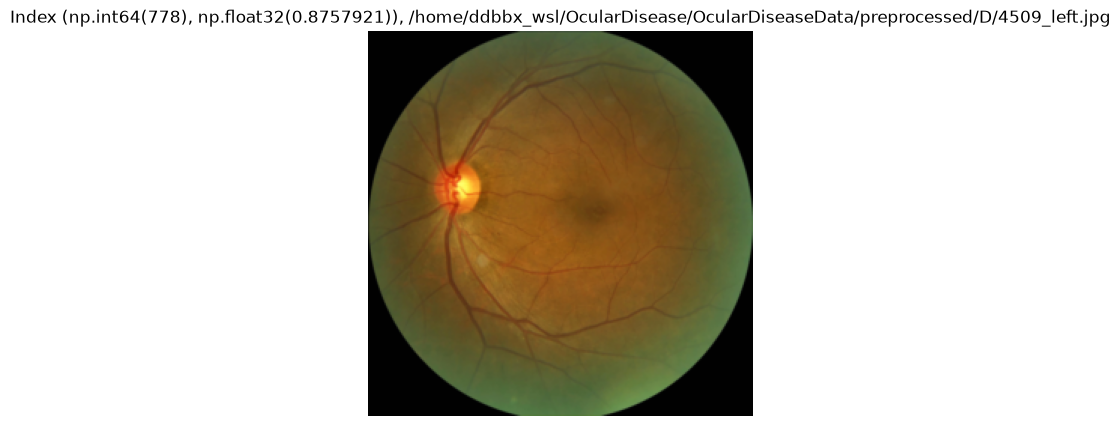

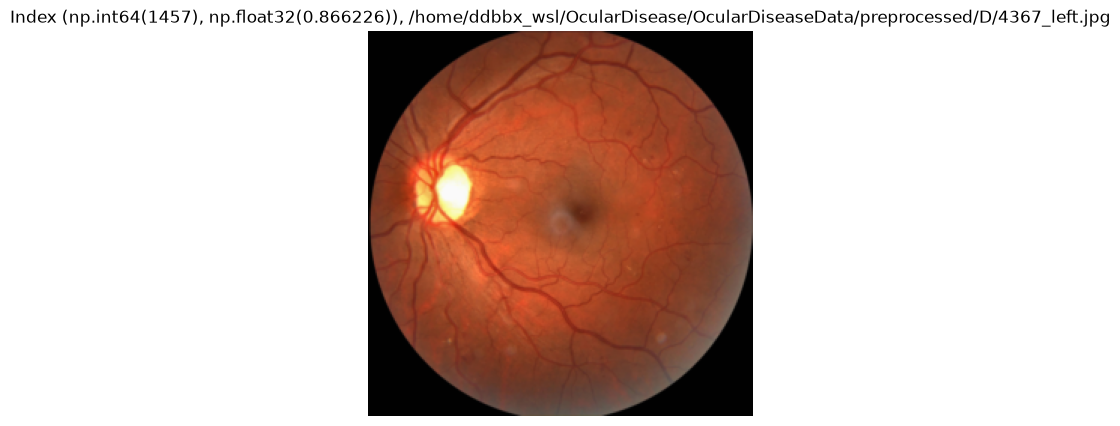

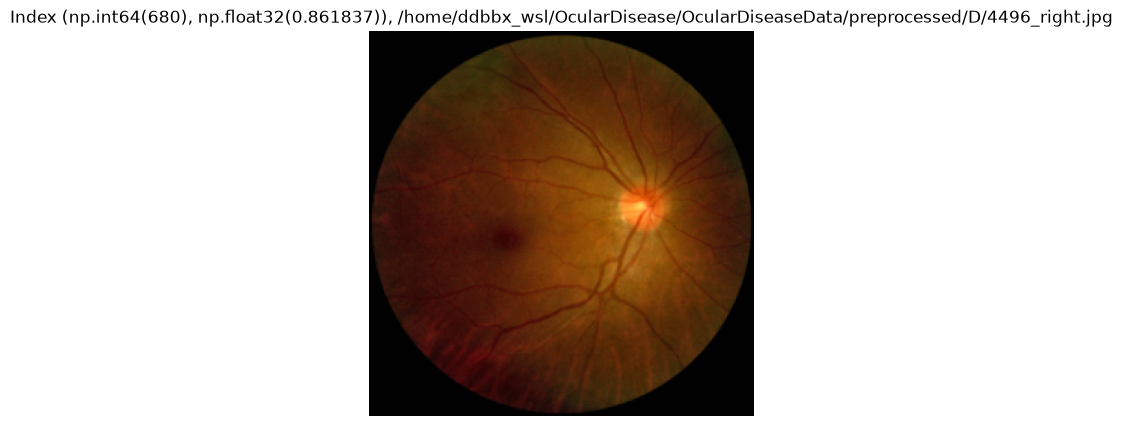

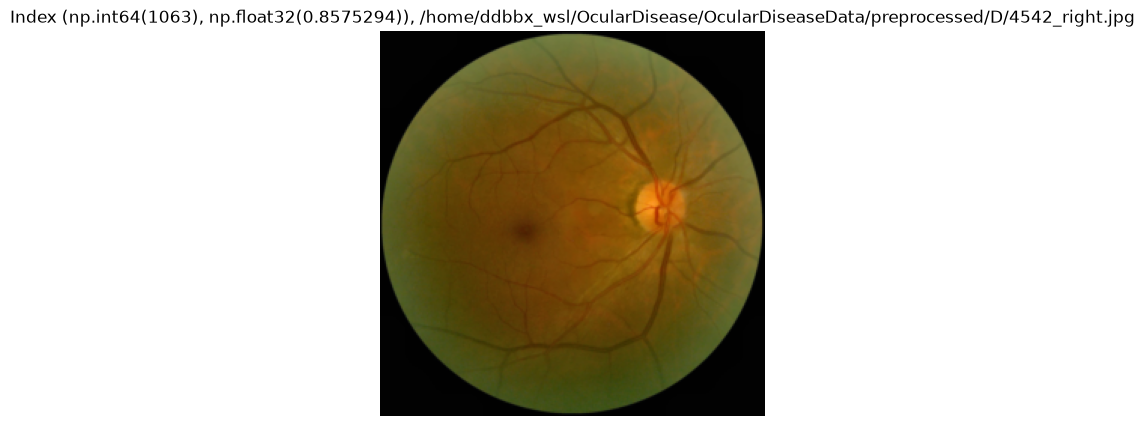

In [46]:
# Review the images

for i in list_class2_to_6[:5]:

    img = test_dataset.images[int(i[0])]

    imgpath = test_paths[int(i[0])]

    plt.figure(figsize=(5,5))
    plt.imshow(img.permute(1,2,0))
    plt.title(f"Index {i}, {imgpath}")
    plt.axis("off")
    plt.show()




## Discussion

Our proposed CNN model is able to produce an overall accuracy of 77%, overall precision of 0.7803, overall recall of 0.7742, and overall F1 score of 0.7749. Meanwhile, the per-class accuracies range from 63% to 99%. The highest being Class 1, Cataract (C), being 99%. Taking a look at the raw images of Class 1, we can observe that the images of this class are very distinctive visually and are easy to identify. This means the features of Class 1 were distinctive enough that our model can easily learnt. The worse class is Class 4, Hypertensive Retinopathy (H), has an accuracy of only 63%. This is due to class 4 has the smallest number of images (420, 4% of total) for the model to train on, a class imbalance issue. In this case, the neural network cannot learn too much about the features of class 4. For Class 2, Diabetic Retinopathy (D), while it has highest number of images (3,128 records), its accuracy is not among the highest ones. From the confusion matrix, we can observe that Class 2 was often mistaken as Class 6 Normal (N), or vice versa. By observing the images of Class 2 being mistaken as Class 6, we found that Class 2 images genuinely look like normal eyes. This means our model cannot efficiently differentiate Class 2 and Class 6 due to their visual similarity. 

Recap  
Per-class Accuracies  
Class 0: 0.8421  
Class 1: 0.9934  
Class 2: 0.7191  
Class 3: 0.7976  
Class 4: 0.6349  
Class 5: 0.7387  
Class 6: 0.7622  

Performance Metrics  
Overall Accuracy:&nbsp;&nbsp;&nbsp;&nbsp;0.7742  
Overall Precision:&nbsp;&nbsp;&nbsp;&nbsp;0.7803  
Overall Recall:&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;0.7742  
Overall F1 Score:&nbsp;&nbsp;&nbsp;&nbsp;0.7749  


To sum up, we have successfully produced an effective classification model that can identify the specific ocular disease of eyes, out of the provided 6 conditions plus 1 normal, when providing the fundus images. Our model has good performance metrics where overall accuracy, precision, recall, and F1 score are all being almost 80%. There may be some minor issues when identifying certain conditions, but the overall architecture itself is good. 



## Future Work

For future work, we can consider the following.

1. We can find more images for Class 4, Hypertensive Retinopathy (H), so we can solve the class imbalance issue.
2. To be able to handle Class 2 more efficiently, we can try other preprocessing methods. For example, we can try identifying the location of the lesion, then crop that region off. Next we can use the lesion only image, without resizing down too much of the resolution, to do the training. 